In [1]:
"""
OPTIMIZED SVM MODEL - FAST VERSION
Uses parallel processing and smart parameter selection
"""

import pandas as pd
import numpy as np
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import pickle
import time
import warnings
from joblib import Parallel, delayed
import multiprocessing
warnings.filterwarnings('ignore')

In [2]:
# ============================================================================
# FAST HYPERPARAMETER TUNING (PARALLEL)
# ============================================================================

def evaluate_svm_params(params, X_train_scaled, y_train, X_val_scaled, y_val):
    """Evaluate a single parameter combination"""
    kernel, C, epsilon, gamma = params
    
    try:
        model = SVR(kernel=kernel, C=C, epsilon=epsilon, gamma=gamma, 
                   cache_size=2000, max_iter=5000)
        model.fit(X_train_scaled, y_train)
        
        y_val_pred = model.predict(X_val_scaled)
        val_r2 = r2_score(y_val, y_val_pred)
        val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
        
        return {
            'kernel': kernel,
            'C': C,
            'epsilon': epsilon,
            'gamma': gamma,
            'val_r2': val_r2,
            'val_rmse': val_rmse,
            'model': model
        }
    except Exception as e:
        return None

def tune_svm_fast(X_train, y_train, X_val, y_val, n_jobs=-1):
    """
    Fast hyperparameter tuning using parallel processing
    """
    print("\n" + "="*80)
    print("FAST SVM HYPERPARAMETER TUNING (Parallel)")
    print("="*80)
    
    # Scale data
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    
    # Reduced parameter grid (smart selection)
    param_grid = {
        'kernel': ['rbf'],  # RBF usually works best
        'C': [1, 10, 50, 100],  # Reduced from 5 to 4 values
        'epsilon': [0.05, 0.1],  # Reduced from 4 to 2 values
        'gamma': ['scale']  # Scale usually better than auto
    }
    
    # Generate all combinations
    param_combinations = [
        (kernel, C, epsilon, gamma)
        for kernel in param_grid['kernel']
        for C in param_grid['C']
        for epsilon in param_grid['epsilon']
        for gamma in param_grid['gamma']
    ]
    
    total = len(param_combinations)
    print(f"\nTotal combinations: {total}")
    print(f"Using {multiprocessing.cpu_count()} CPU cores")
    
    # Parallel execution
    print("\nRunning parallel grid search...")
    start_time = time.time()
    
    results = Parallel(n_jobs=n_jobs, verbose=10)(
        delayed(evaluate_svm_params)(params, X_train_scaled, y_train, 
                                    X_val_scaled, y_val)
        for params in param_combinations
    )
    
    # Filter out failed results
    results = [r for r in results if r is not None]
    
    elapsed = time.time() - start_time
    print(f"\n✓ Grid search completed in {elapsed:.2f} seconds")
    
    # Find best
    best_result = max(results, key=lambda x: x['val_r2'])
    best_params = {k: best_result[k] for k in ['kernel', 'C', 'epsilon', 'gamma']}
    best_model = best_result['model']
    
    print("\n" + "-"*60)
    print("BEST PARAMETERS FOUND:")
    print("-"*60)
    for param, value in best_params.items():
        print(f"  {param}: {value}")
    print(f"  Validation R²: {best_result['val_r2']:.4f}")
    print(f"  Validation RMSE: {best_result['val_rmse']:.4f}")
    print("-"*60)
    
    # Save results
    results_df = pd.DataFrame([{k: r[k] for k in ['kernel', 'C', 'epsilon', 'gamma', 'val_r2', 'val_rmse']} 
                               for r in results])
    results_df = results_df.sort_values('val_r2', ascending=False)
    results_df.to_csv('svm_hyperparameter_tuning_results.csv', index=False)
    print("\n✓ Saved tuning results to: svm_hyperparameter_tuning_results.csv")
    
    # Show top 5
    print("\nTop 5 Parameter Combinations:")
    print(results_df.head().to_string(index=False))
    
    return best_model, scaler, best_params, results_df

In [3]:
# ============================================================================
# IMPROVED SVM TRAINING
# ============================================================================

def train_svm_model_improved(X_train, y_train, X_val, y_val, X_test, y_test, 
                             kernel='rbf', C=1.0, epsilon=0.1, gamma='scale'):
    """
    Train SVM model with proper train/val/test evaluation
    """
    print("\n" + "="*80)
    print("TRAINING SVM MODEL")
    print("="*80)
    
    # Scale features
    print("\nScaling features...")
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)
    
    # Initialize SVM with optimized settings
    print(f"\nTraining SVM with kernel={kernel}, C={C}, epsilon={epsilon}, gamma={gamma}...")
    svm_model = SVR(
        kernel=kernel,
        C=C,
        epsilon=epsilon,
        gamma=gamma,
        cache_size=2000,  # Increased cache
        max_iter=10000,   # Increased max iterations
        verbose=False
    )
    
    # Train
    start_time = time.time()
    svm_model.fit(X_train_scaled, y_train)
    training_time = time.time() - start_time
    print(f"✓ Training completed in {training_time:.2f} seconds")
    
    # Predict on all sets
    print("\nMaking predictions...")
    y_train_pred = svm_model.predict(X_train_scaled)
    y_val_pred = svm_model.predict(X_val_scaled)
    y_test_pred = svm_model.predict(X_test_scaled)
    
    # Evaluate
    print("\n" + "-"*60)
    print("PERFORMANCE METRICS")
    print("-"*60)
    
    # Helper function
    def calc_metrics(y_true, y_pred):
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        return rmse, mae, r2
    
    # Training metrics
    train_rmse, train_mae, train_r2 = calc_metrics(y_train, y_train_pred)
    print("\nTraining Set:")
    print(f"  RMSE: {train_rmse:.4f}")
    print(f"  MAE:  {train_mae:.4f}")
    print(f"  R²:   {train_r2:.4f}")
    
    # Validation metrics
    val_rmse, val_mae, val_r2 = calc_metrics(y_val, y_val_pred)
    print("\nValidation Set:")
    print(f"  RMSE: {val_rmse:.4f}")
    print(f"  MAE:  {val_mae:.4f}")
    print(f"  R²:   {val_r2:.4f}")
    
    # Test metrics
    test_rmse, test_mae, test_r2 = calc_metrics(y_test, y_test_pred)
    print("\nTest Set:")
    print(f"  RMSE: {test_rmse:.4f}")
    print(f"  MAE:  {test_mae:.4f}")
    print(f"  R²:   {test_r2:.4f}")
    
    # Overfitting analysis
    print("\nOverfitting Analysis:")
    print(f"  Train-Val R² Gap:  {train_r2 - val_r2:.4f}")
    print(f"  Train-Test R² Gap: {train_r2 - test_r2:.4f}")
    print(f"  Val-Test R² Gap:   {val_r2 - test_r2:.4f}")
    
    # Model info
    print(f"\nModel Info:")
    print(f"  Support Vectors: {svm_model.n_support_.sum() if hasattr(svm_model, 'n_support_') else len(svm_model.support_vectors_)}")
    print(f"  Training Time: {training_time:.2f}s")
    
    # Visualization
    create_svm_visualizations(y_train, y_train_pred, y_val, y_val_pred, 
                             y_test, y_test_pred)
    
    return svm_model, scaler, {
        'train_rmse': train_rmse, 'train_mae': train_mae, 'train_r2': train_r2,
        'val_rmse': val_rmse, 'val_mae': val_mae, 'val_r2': val_r2,
        'test_rmse': test_rmse, 'test_mae': test_mae, 'test_r2': test_r2,
        'training_time': training_time
    }

In [4]:
# ============================================================================
# VISUALIZATION
# ============================================================================

def create_svm_visualizations(y_train, y_train_pred, y_val, y_val_pred, 
                              y_test, y_test_pred):
    """Create comprehensive visualizations"""
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # 1. Train predictions
    ax1 = axes[0, 0]
    ax1.scatter(y_train, y_train_pred, alpha=0.5, s=10)
    ax1.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 
             'r--', linewidth=2)
    ax1.set_xlabel('Actual FI')
    ax1.set_ylabel('Predicted FI')
    ax1.set_title('Training Set: Predictions vs Actual', fontweight='bold')
    ax1.grid(alpha=0.3)
    train_r2 = r2_score(y_train, y_train_pred)
    ax1.text(0.05, 0.95, f'R² = {train_r2:.4f}', transform=ax1.transAxes, 
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat'))
    
    # 2. Val predictions
    ax2 = axes[0, 1]
    ax2.scatter(y_val, y_val_pred, alpha=0.5, s=10, color='orange')
    ax2.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 
             'r--', linewidth=2)
    ax2.set_xlabel('Actual FI')
    ax2.set_ylabel('Predicted FI')
    ax2.set_title('Validation Set: Predictions vs Actual', fontweight='bold')
    ax2.grid(alpha=0.3)
    val_r2 = r2_score(y_val, y_val_pred)
    ax2.text(0.05, 0.95, f'R² = {val_r2:.4f}', transform=ax2.transAxes, 
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat'))
    
    # 3. Test predictions
    ax3 = axes[0, 2]
    ax3.scatter(y_test, y_test_pred, alpha=0.5, s=10, color='green')
    ax3.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', linewidth=2)
    ax3.set_xlabel('Actual FI')
    ax3.set_ylabel('Predicted FI')
    ax3.set_title('Test Set: Predictions vs Actual', fontweight='bold')
    ax3.grid(alpha=0.3)
    test_r2 = r2_score(y_test, y_test_pred)
    ax3.text(0.05, 0.95, f'R² = {test_r2:.4f}', transform=ax3.transAxes, 
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat'))
    
    # 4. Residuals - Train
    ax4 = axes[1, 0]
    residuals_train = y_train - y_train_pred
    ax4.hist(residuals_train, bins=50, edgecolor='black', alpha=0.7)
    ax4.axvline(0, color='red', linestyle='--', linewidth=2)
    ax4.set_xlabel('Residual')
    ax4.set_ylabel('Frequency')
    ax4.set_title('Training Residuals', fontweight='bold')
    ax4.grid(alpha=0.3)
    
    # 5. Residuals - Val
    ax5 = axes[1, 1]
    residuals_val = y_val - y_val_pred
    ax5.hist(residuals_val, bins=50, edgecolor='black', alpha=0.7, color='orange')
    ax5.axvline(0, color='red', linestyle='--', linewidth=2)
    ax5.set_xlabel('Residual')
    ax5.set_ylabel('Frequency')
    ax5.set_title('Validation Residuals', fontweight='bold')
    ax5.grid(alpha=0.3)
    
    # 6. R² Comparison
    ax6 = axes[1, 2]
    r2_scores = [train_r2, val_r2, test_r2]
    sets = ['Train', 'Val', 'Test']
    colors = ['steelblue', 'orange', 'green']
    bars = ax6.bar(sets, r2_scores, color=colors, edgecolor='black', alpha=0.8)
    ax6.set_ylabel('R² Score')
    ax6.set_title('R² Comparison Across Sets', fontweight='bold')
    ax6.set_ylim([0, max(r2_scores) * 1.2])
    ax6.grid(alpha=0.3, axis='y')
    for bar, score in zip(bars, r2_scores):
        height = bar.get_height()
        ax6.text(bar.get_x() + bar.get_width()/2., height,
                f'{score:.4f}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('svm_performance_validation.png', dpi=300)
    print("\n✓ Saved visualization: svm_performance_validation.png")

OPTIMIZED SVM MODEL (FAST VERSION)

1. LOADING DATA (Train/Val/Test)
------------------------------------------------------------
X_train shape: (11397, 19)
X_val shape: (3397, 19)
X_test shape: (8248, 19)
y_train shape: (11397,)
y_val shape: (3397,)
y_test shape: (8248,)

Missing values: Train=0, Val=0, Test=0

2. QUICK TRAINING WITH DEFAULT PARAMETERS
------------------------------------------------------------

TRAINING SVM MODEL

Scaling features...

Training SVM with kernel=rbf, C=10, epsilon=0.1, gamma=scale...
✓ Training completed in 0.02 seconds

Making predictions...

------------------------------------------------------------
PERFORMANCE METRICS
------------------------------------------------------------

Training Set:
  RMSE: 0.0409
  MAE:  0.0336
  R²:   0.5108

Validation Set:
  RMSE: 0.0390
  MAE:  0.0314
  R²:   0.4424

Test Set:
  RMSE: 0.0491
  MAE:  0.0413
  R²:   0.2009

Overfitting Analysis:
  Train-Val R² Gap:  0.0684
  Train-Test R² Gap: 0.3099
  Val-Test R² Gap

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   8 | elapsed:    1.3s remaining:    3.8s
[Parallel(n_jobs=-1)]: Done   3 out of   8 | elapsed:    1.3s remaining:    2.2s
[Parallel(n_jobs=-1)]: Done   4 out of   8 | elapsed:    1.4s remaining:    1.4s
/Users/absarkar/Developer/Capstone_Code/capstone_venv/lib/python3.14/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/absarkar/Developer/Capstone_Code/capstone_venv/lib/python3.14/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/absarkar/Developer/Capstone_Code/capstone_venv/lib/python3.14/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter


✓ Grid search completed in 1.71 seconds

------------------------------------------------------------
BEST PARAMETERS FOUND:
------------------------------------------------------------
  kernel: rbf
  C: 1
  epsilon: 0.05
  gamma: scale
  Validation R²: 0.5000
  Validation RMSE: 0.0369
------------------------------------------------------------

✓ Saved tuning results to: svm_hyperparameter_tuning_results.csv

Top 5 Parameter Combinations:
kernel   C  epsilon gamma   val_r2  val_rmse
   rbf   1     0.05 scale 0.499973  0.036909
   rbf  10     0.05 scale 0.454999  0.038533
   rbf  50     0.05 scale 0.454999  0.038533
   rbf 100     0.05 scale 0.454999  0.038533
   rbf   1     0.10 scale 0.442429  0.038975

4. TRAINING FINAL MODEL WITH BEST PARAMETERS
------------------------------------------------------------

TRAINING SVM MODEL

Scaling features...

Training SVM with kernel=rbf, C=1, epsilon=0.05, gamma=scale...
✓ Training completed in 0.22 seconds

Making predictions...

---------

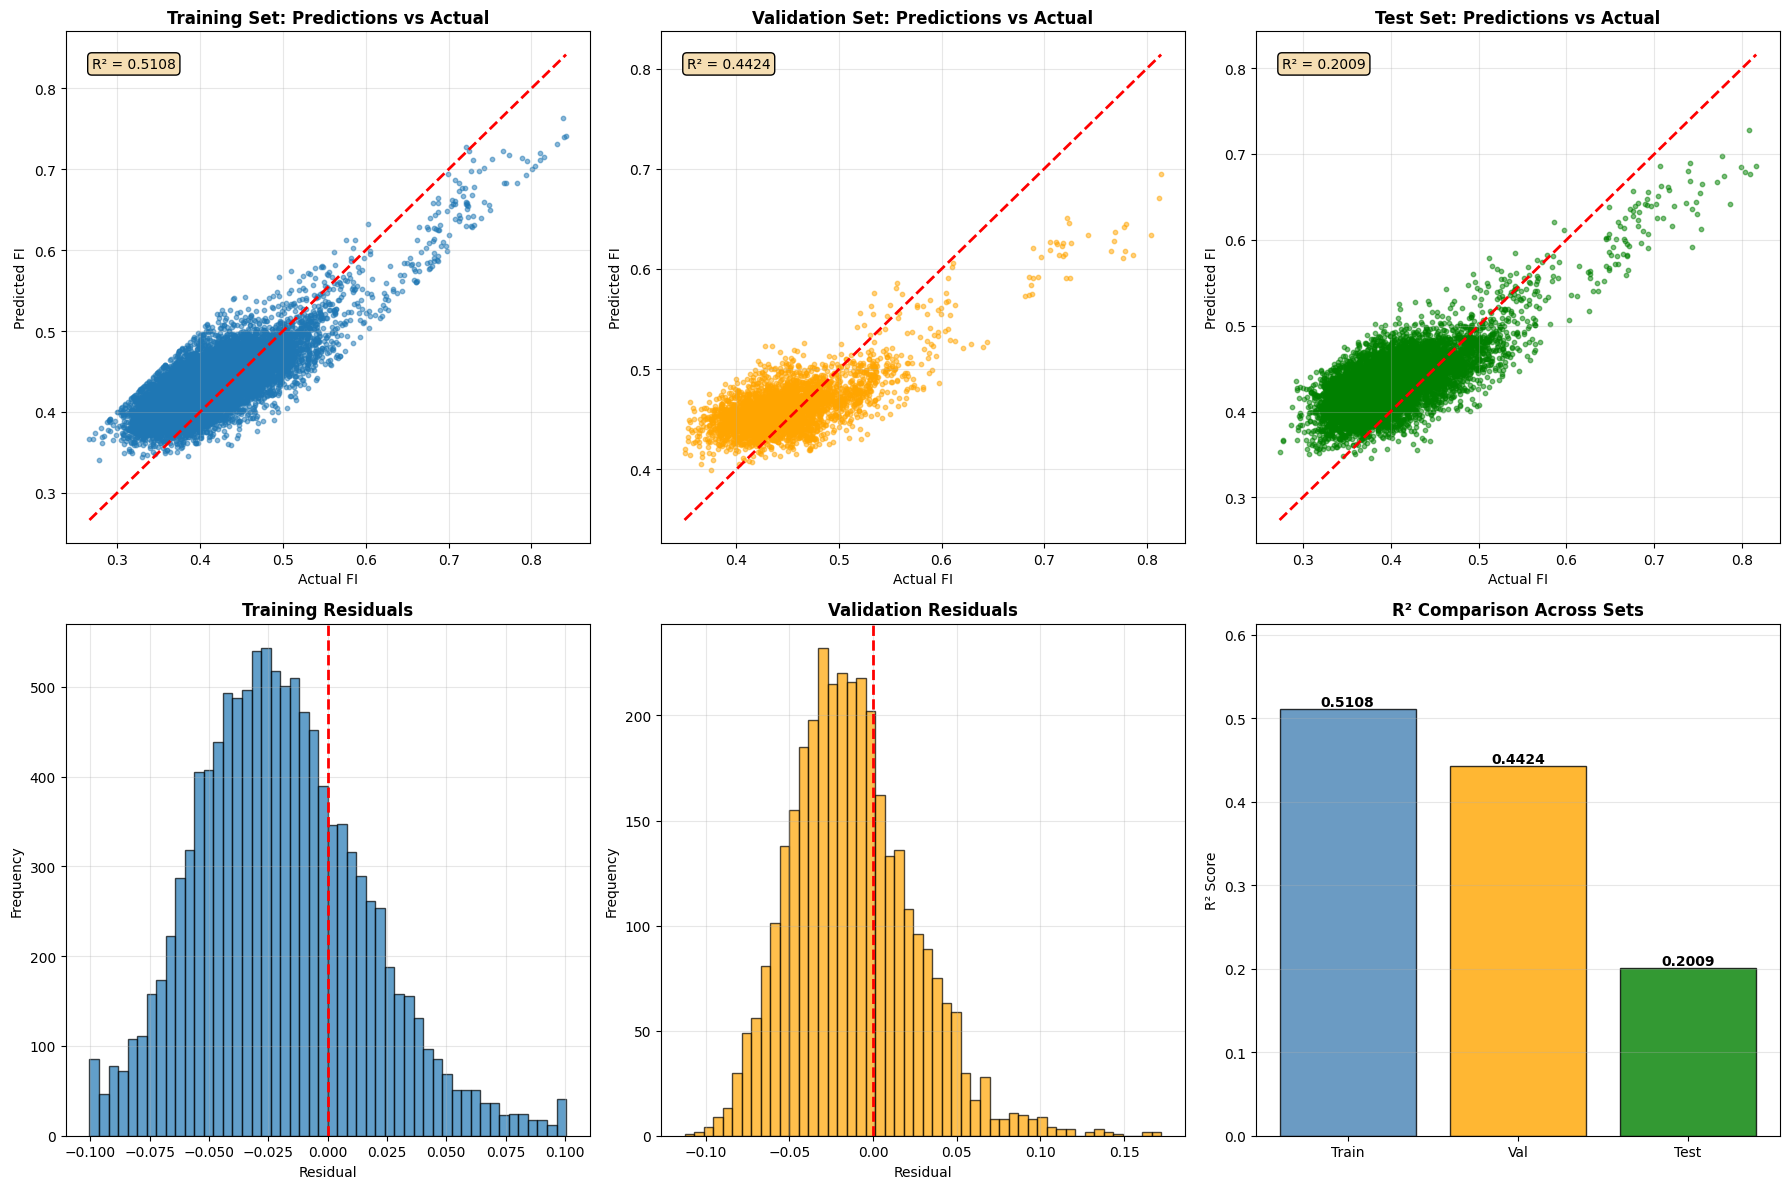

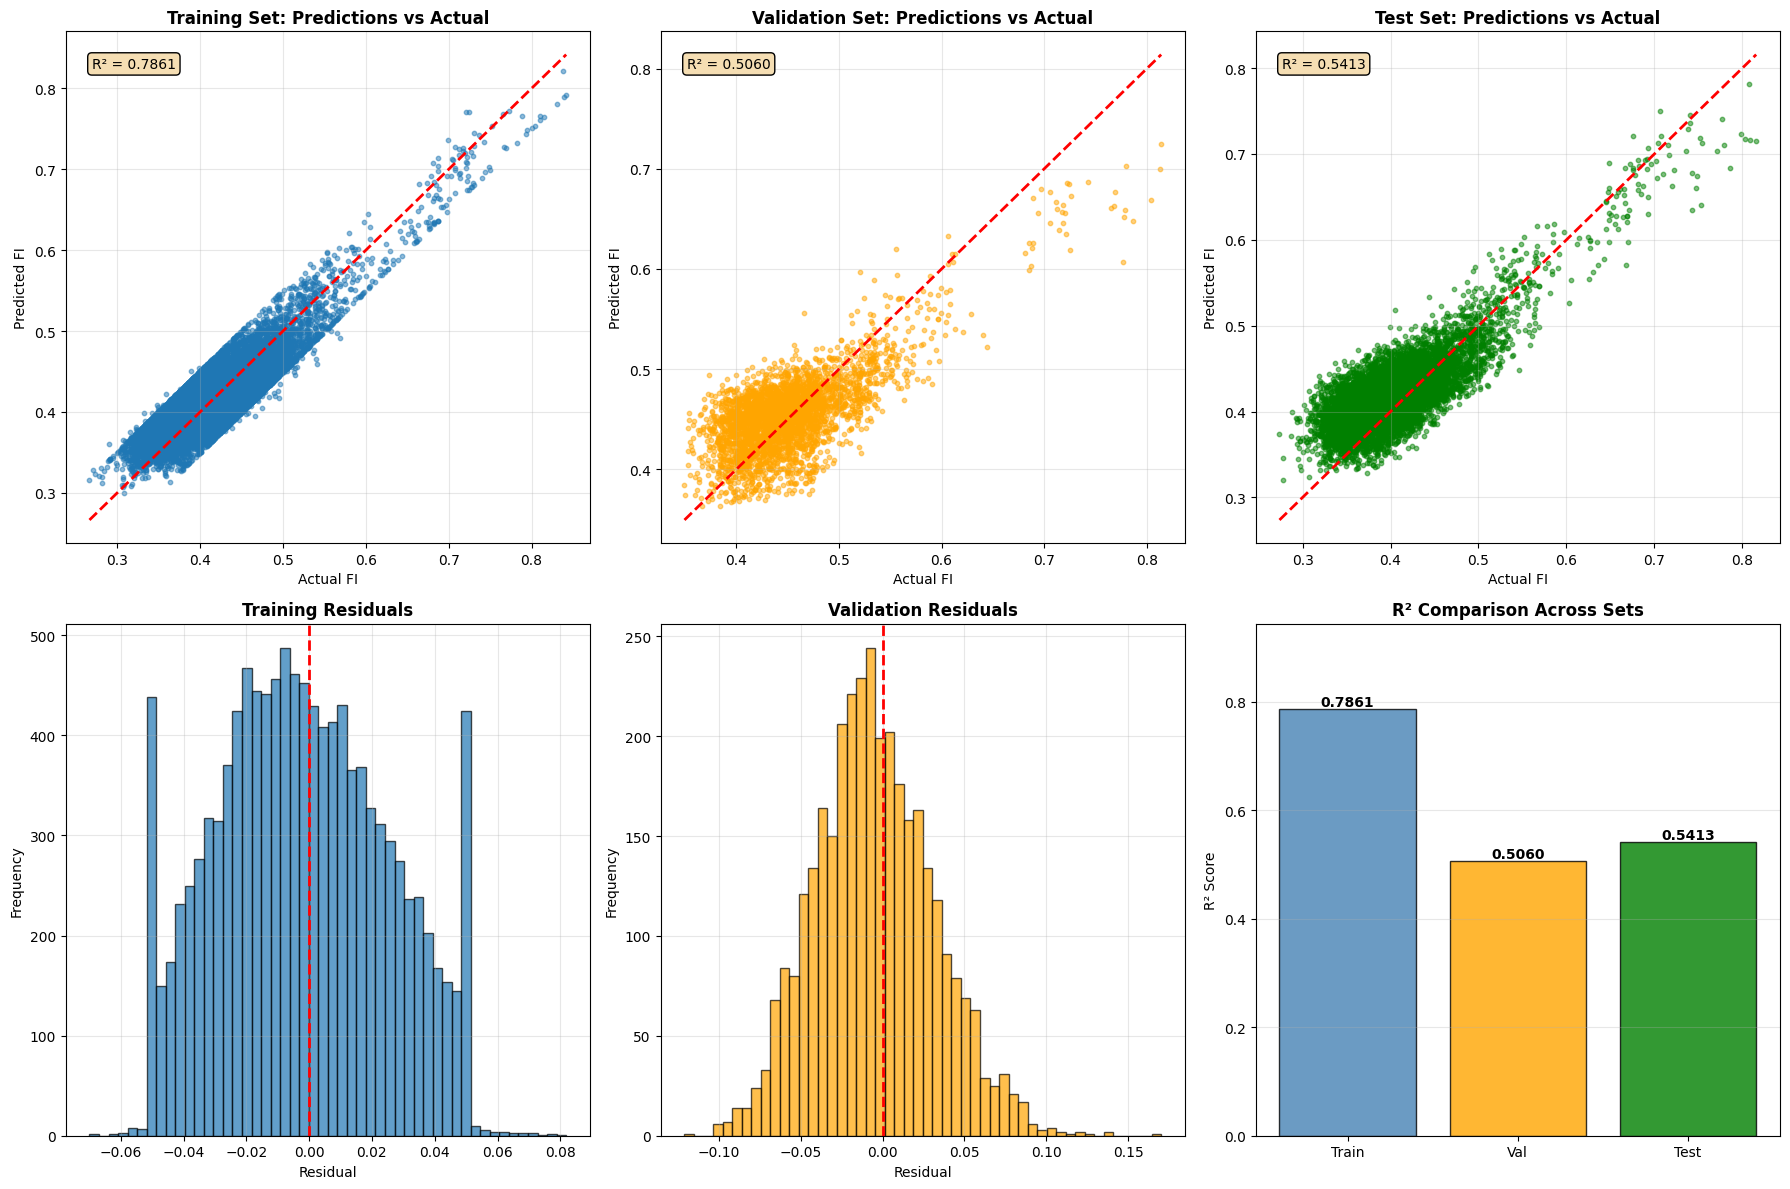

In [5]:
# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    
    print("="*80)
    print("OPTIMIZED SVM MODEL (FAST VERSION)")
    print("="*80)
    
    # Load data
    print("\n1. LOADING DATA (Train/Val/Test)")
    print("-" * 60)
    
    X_train = pd.read_csv('csv/X_train.csv')
    X_val = pd.read_csv('csv/X_val.csv')
    X_test = pd.read_csv('csv/X_test.csv')
    y_train = pd.read_csv('csv/y_train.csv').iloc[:, 0].values
    y_val = pd.read_csv('csv/y_val.csv').iloc[:, 0].values
    y_test = pd.read_csv('csv/y_test.csv').iloc[:, 0].values
    
    print(f"X_train shape: {X_train.shape}")
    print(f"X_val shape: {X_val.shape}")
    print(f"X_test shape: {X_test.shape}")
    print(f"y_train shape: {y_train.shape}")
    print(f"y_val shape: {y_val.shape}")
    print(f"y_test shape: {y_test.shape}")
    
    # Features
    features_to_use = [
        'Rain_log', 'Temp', 'LST',
        'green_fraction_boxcox',
        'BulkDensity',
        'Elevation', 'Slope_log',
        'AOD_log', 'NO2_log', 'SO2',
        'Month_Sin', 'Month_Cos',
        'longitude', 'latitude'
    ]
    
    X_train_clean = X_train[features_to_use]
    X_val_clean = X_val[features_to_use]
    X_test_clean = X_test[features_to_use]
    
    # Check for missing values
    print(f"\nMissing values: Train={X_train_clean.isnull().sum().sum()}, Val={X_val_clean.isnull().sum().sum()}, Test={X_test_clean.isnull().sum().sum()}")
    
    # Option 1: Quick training with default params
    print("\n2. QUICK TRAINING WITH DEFAULT PARAMETERS")
    print("-" * 60)
    
    svm_default, scaler_default, metrics_default = train_svm_model_improved(
        X_train_clean, y_train,
        X_val_clean, y_val,
        X_test_clean, y_test,
        kernel='rbf',
        C=10,
        epsilon=0.1,
        gamma='scale'
    )
    
    # Option 2: Fast hyperparameter tuning
    print("\n3. HYPERPARAMETER TUNING")
    print("-" * 60)
    
    response = input("\nDo you want to run FAST hyperparameter tuning? (y/n): ")
    
    if response.lower() == 'y':
        best_model, best_scaler, best_params, tuning_results = tune_svm_fast(
            X_train_clean, y_train, X_val_clean, y_val, n_jobs=-1
        )
        
        # Train final model with best params
        print("\n4. TRAINING FINAL MODEL WITH BEST PARAMETERS")
        print("-" * 60)
        
        svm_final, scaler_final, metrics_final = train_svm_model_improved(
            X_train_clean, y_train,
            X_val_clean, y_val,
            X_test_clean, y_test,
            **best_params
        )
        
        # Save best model
        model_to_save = svm_final
        scaler_to_save = scaler_final
        metrics_to_save = metrics_final
        params_to_save = best_params
    else:
        model_to_save = svm_default
        scaler_to_save = scaler_default
        metrics_to_save = metrics_default
        params_to_save = {'kernel': 'rbf', 'C': 10, 'epsilon': 0.1, 'gamma': 'scale'}
    
    # Save model
    print("\n5. SAVING MODEL")
    print("-" * 60)
    
    model_data = {
        'model': model_to_save,
        'scaler': scaler_to_save,
        'features': features_to_use,
        'metrics': metrics_to_save,
        'params': params_to_save
    }
    
    with open('svm_model_improved.pkl', 'wb') as f:
        pickle.dump(model_data, f)
    
    print("✓ Model saved to svm_model_improved.pkl")
    
    # Summary
    print("\n" + "="*80)
    print("✅ OPTIMIZED SVM MODEL COMPLETE")
    print("="*80)
    print(f"\n📊 FINAL RESULTS:")
    print(f"  Train R²: {metrics_to_save['train_r2']:.4f}")
    print(f"  Val R²:   {metrics_to_save['val_r2']:.4f}")
    print(f"  Test R²:  {metrics_to_save['test_r2']:.4f}")
    print(f"  Test RMSE: {metrics_to_save['test_rmse']:.4f}")
    print(f"  Test MAE:  {metrics_to_save['test_mae']:.4f}")
    print("\n" + "="*80)